# Stage 10 Validation And Sensitivity Verification

This notebook explains and verifies the completed Stage 10 validation step:

- `cache/10_validation_sensitivity_summary.json`
- `cache/10_completeness_statement.md`
- `cache/09_characterization_probability_v1.h5`
- `cache/09_characterization_probability_summary.json`

The goal is human verification, not production. The cells below load the final artifacts, show the physics assumptions, and expose the numerical checks behind the final conditional completeness statement.

## What Stage 10 Is Checking

Stage 09 produced a map:

`P(characterized | tau_135, E)`

Stage 10 asks whether that map can support a final completeness statement. It checks four things:

1. Known characterized traps should land in high-probability regions of the map.
2. Completeness versus `tau_135` should be reported after averaging over the observed characterized-trap `E` distribution.
3. The analytic Method 3 map should be compared to the older empirical Method 2 sensitivity bands.
4. The final language must be conditional: it is a recoverable-completeness statement under the observed/high-confidence amplitude prior and observed `E` distribution, not an unconditional population bound.

## Physics Reminder

The per-temperature signal model is the pocket-pumping dipole intensity curve:

`I(t_ph; tau, A) = A * (exp(-t_ph/tau) - exp(-8*t_ph/tau))`

where `A = N_pumps * D_t * P_c(T)`. The peak intensity is about `0.65 A` if the peak delay is sampled. Long `tau` traps are not intrinsically faint; they become hard because the measurement cannot reach their peak, so the observed curve stays on the rising edge.

For a physical trap with fixed `E` and cross-section, `tau(T)` is computed with `dipole.log_energy_cross_section`. Stage 09 combines the per-temperature detection probabilities using the Poisson-binomial probability that at least `n_good` temperatures are detected. Stage 10 then averages that map over the observed characterized-trap `E` distribution.

## Cached Figures

These figures were generated by `src/validation_sensitivity.py` during Stage 10.

![Known trap probability histogram](../cache/figures/10_known_trap_probability_hist.png)

![Completeness versus tau_135](../cache/figures/10_completeness_vs_tau.png)

![Method 2 versus Method 3](../cache/figures/10_method2_vs_method3_hist.png)

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib import colors
from matplotlib import cm, ticker

# plotting specifications
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

smaller= 20
small = 24
medium = 30
large = 36

params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
plt.rcParams['figure.figsize']=(5,5)
plt.rcParams['axes.formatter.use_mathtext']=True

In [2]:
from pathlib import Path
import csv
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "trap_completeness_method3" / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find repo root from current working directory")


repo = find_repo_root()
work = repo / "trap_completeness_method3"
cache = work / "cache"

summary_path = cache / "10_validation_sensitivity_summary.json"
statement_path = cache / "10_completeness_statement.md"
stage09_h5_path = cache / "09_characterization_probability_v1.h5"
records4_path = cache / "01_records_ngood4.csv"

summary = json.loads(summary_path.read_text())
statement = statement_path.read_text()

print("Stage 10 produced at:", summary["produced_at"])
print("Thermal model source:", summary["model_notes"]["thermal_model_source"])
print("Stage 09 recompute max abs diff:", summary["model_notes"]["stage09_default_recompute_check_max_abs"])


Stage 10 produced at: 2026-05-25T13:06:09-07:00
Thermal model source: dipole.log_energy_cross_section
Stage 09 recompute max abs diff: 1.4377388168895777e-14


## Final Statement

This is the exact markdown statement saved by Stage 10. It is intentionally worded as conditional recoverable completeness.

In [3]:
print(statement)


# Method 3 Conditional Completeness Statement

Using the Stage 08 injection-recovery grid and the Stage 05 high-confidence amplitude prior, the Stage 09 characterization map is validated by the observed characterized traps: 99.8595% of the `n_good = 4` known traps fall at `P_4 >= 0.8`, with median `P_4 = 0.99999996`.

Averaging `P(characterized | tau_135, E)` over the observed `n_good = 4` energy distribution gives mean completeness of 1.000 at `tau_135 = 1 s`, 1.000 at `10 s`, 0.995 at `100 s`, 0.936 at `10^3 s`, and 0.686 at `10^4 s`.
The default conditional curve is at least 95% complete on the Stage 09 grid from `tau_135 = 0.000624` to `701 s`.
It is at least 90% complete from `tau_135 = 0.000372` to `1.66e+03 s`.

This is a recoverable-completeness statement, not an unconditional population bound. It assumes hidden traps share the observed `E` distribution and the observed/high-confidence trap-depth prior. Under fainter amplitude priors, the `n_good = 4` mean probability at `tau_1

## Artifact Shape And Round-Trip Checks

The key reproducibility check is that Stage 10 can recompute the default `n_good = 4` Stage 09 map using the exact `dipole.log_energy_cross_section` model. The maximum absolute difference is at numerical precision, which means the sensitivity variants use the same physics mapping as Stage 09.

In [4]:
with h5py.File(stage09_h5_path, "r") as h5:
    tau_grid = h5["grid/tau_135_seconds"][:]
    E_grid = h5["grid/E_eV"][:]
    p4_map = h5["results/p_characterized_n_good_4"][:]
    p3_map = h5["results/p_characterized_n_good_3"][:]
    all_oob = h5["diagnostics/all_temperatures_tau_oob"][:].astype(bool)
    known_p4 = h5["validation_known_traps/n_good_4_csv/p_characterized_n_good_4"][:]
    known_tau = h5["validation_known_traps/n_good_4_csv/tau_135_seconds"][:]
    known_E = h5["validation_known_traps/n_good_4_csv/E_eV"][:]

print("Stage 09 p4 map shape:", p4_map.shape)
print("tau_135 grid:", tau_grid[0], "to", tau_grid[-1], "seconds; count", len(tau_grid))
print("E grid:", E_grid[0], "to", E_grid[-1], "eV; count", len(E_grid))
print("Known n_good=4 traps:", len(known_p4))
print("Round-trip max abs difference:", summary["model_notes"]["stage09_default_recompute_check_max_abs"])
print("Round-trip p99 abs difference:", summary["model_notes"]["stage09_default_recompute_check_p99_abs"])


Stage 09 p4 map shape: (171, 121)
tau_135 grid: 2e-05 to 100000000.0 seconds; count 171
E grid: 0.04 to 0.7 eV; count 121
Known n_good=4 traps: 2135
Round-trip max abs difference: 1.4377388168895777e-14
Round-trip p99 abs difference: 3.497202527569243e-15


## Known Trap Overlay

Known characterized traps are not used to define the Method 3 grid response. They are a validation overlay. If many real characterized traps sat in low predicted probability regions, that would be a warning that the detection model is missing something important.

fraction_ge_0p5: 0.9995316159250586
fraction_ge_0p8: 0.9985948477751756
fraction_ge_0p9: 0.9985948477751756
median: 0.999999961289453
min: 0.014516909503459212


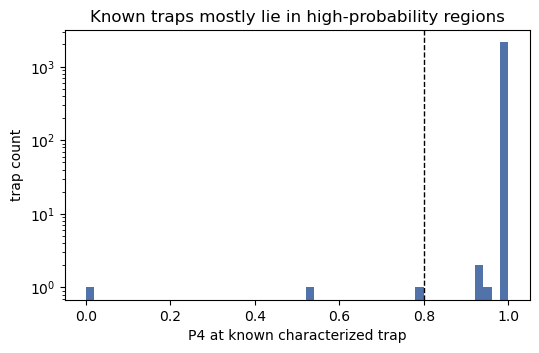

In [5]:
known = summary["known_trap_overlay"]["n_good_4_known_traps"]["p_characterized_n_good_4"]
for key in ["fraction_ge_0p5", "fraction_ge_0p8", "fraction_ge_0p9", "median", "min"]:
    print(f"{key}: {known[key]}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(known_p4, bins=np.linspace(0, 1, 51), color="#325a9b", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("P4 at known characterized trap")
ax.set_ylabel("trap count")
ax.axvline(0.8, color="black", linestyle="--", linewidth=1)
ax.set_title("Known traps mostly lie in high-probability regions")
plt.show()


## Completeness Versus tau_135 Under Observed E

The final completeness curve is not a flat average over the whole `(tau_135, E)` grid. It is the Stage 09 probability map averaged over the observed `E` values from the characterized `n_good = 4` trap CSV. This is why the statement is conditional on the observed `E` distribution.

Representative cached points:
tau_135=     1 s: mean P4 = 0.999948
tau_135=    10 s: mean P4 = 0.999982
tau_135=   100 s: mean P4 = 0.994592
tau_135=  1000 s: mean P4 = 0.935839
tau_135= 10000 s: mean P4 = 0.685516
tau_135=100000 s: mean P4 = 0.080190


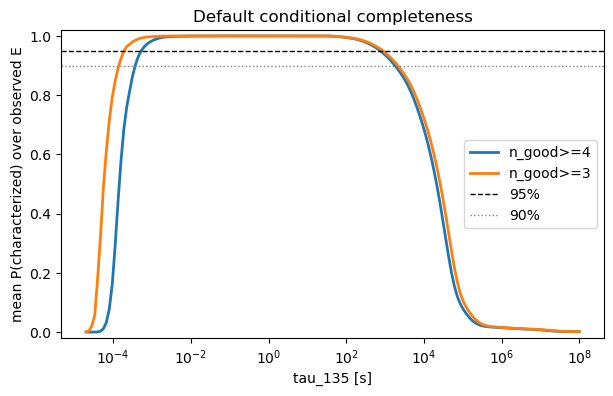

In [6]:
def load_observed_E(path):
    values = []
    with path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            values.append(float(row["E_eV"]))
    return np.asarray(values)


observed_E = load_observed_E(records4_path)
default_curve = np.array([np.interp(observed_E, E_grid, row).mean() for row in p4_map])
default_curve3 = np.array([np.interp(observed_E, E_grid, row).mean() for row in p3_map])
summary_points = summary["completeness_vs_tau_observed_E"]["default_n_good_4"]["representative_tau_seconds_to_mean_probability"]

print("Representative cached points:")
for tau in ["1", "10", "100", "1000", "10000", "100000"]:
    print(f"tau_135={tau:>6} s: mean P4 = {summary_points[tau]:.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau_grid, default_curve, label="n_good>=4", linewidth=2)
ax.plot(tau_grid, default_curve3, label="n_good>=3", linewidth=2)
ax.axhline(0.95, color="black", linestyle="--", linewidth=1, label="95%")
ax.axhline(0.90, color="gray", linestyle=":", linewidth=1, label="90%")
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("tau_135 [s]")
ax.set_ylabel("mean P(characterized) over observed E")
ax.legend()
ax.set_title("Default conditional completeness")
plt.show()


Histogram source: rebuilt from 01_records_ngood4.csv using tau_at_135k_hist.npz bin edges
Trap count in histogram bins: 2135
Tau sample count: 2135


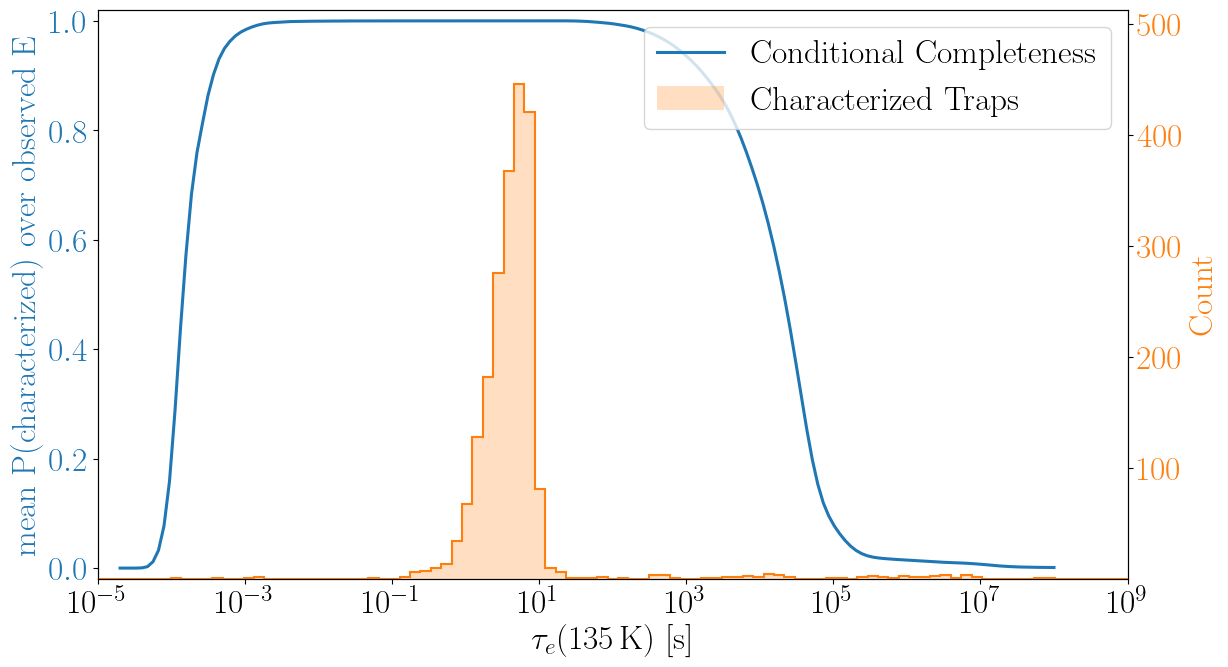

In [37]:
tau_hist_path = repo / "tau_at_135k_hist.npz"
tau_hist_data = np.load(tau_hist_path)
tau_edges = tau_hist_data["bin_edges"]
tau_samples = tau_hist_data["tau_at_135s"]
tau_hist = tau_hist_data["hist"]
hist_source = tau_hist_path.name

# Some local NPZs have the bin edges but no stored traps/histogram. If so, rebuild the histogram
# from the Stage 01 characterized-trap CSV, which stores the same tau_135 quantity.
if tau_samples.size:
    tau_hist, tau_edges = np.histogram(tau_samples, bins=tau_edges)
elif int(np.sum(tau_hist)) == 0:
    tau_samples = []
    with records4_path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            tau_samples.append(float(row["tau_135_seconds"]))
    tau_samples = np.asarray(tau_samples, dtype=float)
    tau_hist, tau_edges = np.histogram(tau_samples, bins=tau_edges)
    hist_source = f"rebuilt from {records4_path.name} using {tau_hist_path.name} bin edges"

print(f"Histogram source: {hist_source}")
print(f"Trap count in histogram bins: {int(tau_hist.sum())}")
print(f"Tau sample count: {tau_samples.size}")

fig, ax = plt.subplots(figsize=(16*0.8, 9*0.8))
ax.plot(tau_grid, default_curve, color="tab:blue", linewidth=2.2, label="Conditional Completeness")
# ax.axhline(0.95, color="black", linestyle="--", linewidth=1, label="95% completeness")
# ax.axhline(0.90, color="gray", linestyle=":", linewidth=1, label="90% completeness")
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("$\\tau_e(135\,\mathrm{K})$ [s]")
ax.set_ylabel("mean P(characterized) over observed E", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax_hist = ax.twinx()
ax_hist.stairs(tau_hist, tau_edges, fill=True, color="tab:orange", alpha=0.25, label="Characterized Traps")
ax_hist.stairs(tau_hist, tau_edges, color="tab:orange", linewidth=1.5)
ax_hist.set_ylabel("Count", color="tab:orange")
ax_hist.tick_params(axis="y", labelcolor="tab:orange")
ax_hist.yaxis.get_major_ticks()[0].set_visible(False)

if np.max(tau_hist) > 0:
    ax_hist.set_ylim(0, np.max(tau_hist) * 1.15)

x_min = min(tau_grid[0], tau_edges[0])
x_max = max(tau_grid[-1], tau_edges[-1])
ax.set_xlim(x_min, x_max)

lines, labels = ax.get_legend_handles_labels()
hist_lines, hist_labels = ax_hist.get_legend_handles_labels()
ax.legend(lines + hist_lines, labels + hist_labels, loc="upper right", fontsize=small)
# ax.set_title("Completeness curve overlaid on tau_at_135k trap histogram")
# plt.grid(which='both',axis='x',color='slategrey')
plt.show()


## Direct 135 K Measurements Versus Extrapolated tau_135

The `tau_at_135k` histogram mixes two cases: traps with a good direct 135 K intensity fit, and traps whose `tau_135` comes only from the fitted `(E, sigma)` thermal model. The split below helps diagnose why the two populations overlap. A trap can fail to be directly measured at 135 K but still be characterized at neighboring temperatures, so its extrapolated `tau_135` can land in the same lifetime range as directly measured traps.

Direct good 135 K tau fits: 242
Extrapolated-only tau_135 values: 1893
Median tau_135 direct 135 K: 1.7365230006034342
Median tau_135 extrapolated-only: 4.91699633961438


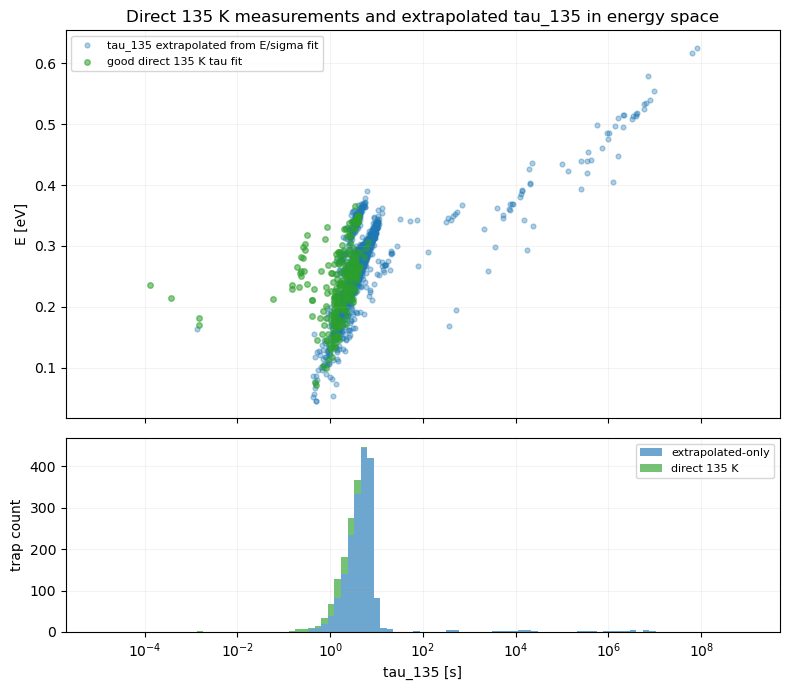

In [9]:
def parse_bool(value):
    return str(value).strip().lower() in {"true", "1", "yes"}


tau_135_records = []
E_records = []
measured_135 = []
with records4_path.open(newline="") as handle:
    for row in csv.DictReader(handle):
        tau_135_records.append(float(row["tau_135_seconds"]))
        E_records.append(float(row["E_eV"]))
        measured_135.append(parse_bool(row["tau_135_good_intensity_fit"]))

tau_135_records = np.asarray(tau_135_records, dtype=float)
E_records = np.asarray(E_records, dtype=float)
measured_135 = np.asarray(measured_135, dtype=bool)
extrapolated_135 = ~measured_135

print(f"Direct good 135 K tau fits: {int(measured_135.sum())}")
print(f"Extrapolated-only tau_135 values: {int(extrapolated_135.sum())}")
print("Median tau_135 direct 135 K:", np.median(tau_135_records[measured_135]))
print("Median tau_135 extrapolated-only:", np.median(tau_135_records[extrapolated_135]))

fig, (ax_scatter, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)

ax_scatter.scatter(
    tau_135_records[extrapolated_135],
    E_records[extrapolated_135],
    s=12,
    alpha=0.35,
    color="tab:blue",
    label="tau_135 extrapolated from E/sigma fit",
)
ax_scatter.scatter(
    tau_135_records[measured_135],
    E_records[measured_135],
    s=16,
    alpha=0.55,
    color="tab:green",
    label="good direct 135 K tau fit",
)
ax_scatter.set_xscale("log")
ax_scatter.set_ylabel("E [eV]")
ax_scatter.set_title("Direct 135 K measurements and extrapolated tau_135 in energy space")
ax_scatter.legend(fontsize=8, loc="best")
ax_scatter.grid(True, which="both", alpha=0.15)

hist_bins = tau_edges
ax_hist.hist(
    [tau_135_records[extrapolated_135], tau_135_records[measured_135]],
    bins=hist_bins,
    stacked=True,
    color=["tab:blue", "tab:green"],
    alpha=0.65,
    label=["extrapolated-only", "direct 135 K"],
)
ax_hist.set_xscale("log")
ax_hist.set_xlabel("tau_135 [s]")
ax_hist.set_ylabel("trap count")
ax_hist.legend(fontsize=8, loc="best")
ax_hist.grid(True, which="both", alpha=0.15)

plt.tight_layout()
plt.show()


## Direct 135 K Split In Energy Versus Cross-Section Space

Energy alone overlaps because it controls the temperature dependence of `tau(T)`, not the absolute lifetime at 135 K by itself. At fixed energy, changing the fitted cross-section shifts the whole lifetime curve up or down. This plot checks whether the direct/extrapolated split is clearer in the physical `(sigma, E)` plane.

The gray contours are constant `tau_135` curves computed from the same `dipole.log_energy_cross_section` model. If the split is mostly a lifetime-window effect, direct 135 K measurements should preferentially lie near contours that the 135 K delay sampling can fit, while extrapolated-only traps can overlap in energy but move away in cross-section.

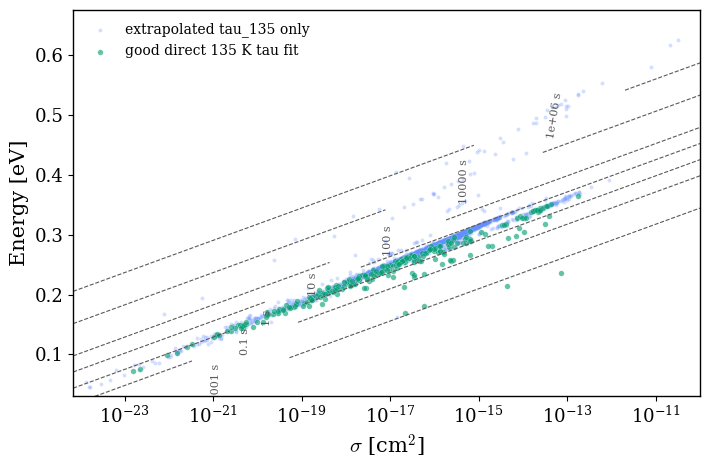

Median sigma direct 135 K: 7.895254962464057e-18
Median sigma extrapolated-only: 1.3009518160078035e-16
Median tau_135 direct 135 K: 1.7365230006034342
Median tau_135 extrapolated-only: 4.91699633961438


In [10]:
import sys

if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from dipole import log_energy_cross_section


sigma_135_split = []
E_135_split = []
tau_135_split = []
direct_135_split = []
with records4_path.open(newline="") as handle:
    for row in csv.DictReader(handle):
        sigma_135_split.append(np.exp(float(row["log_sigma"])))
        E_135_split.append(float(row["E_eV"]))
        tau_135_split.append(float(row["tau_135_seconds"]))
        direct_135_split.append(parse_bool(row["tau_135_good_intensity_fit"]))

sigma_135_split = np.asarray(sigma_135_split, dtype=float)
E_135_split = np.asarray(E_135_split, dtype=float)
tau_135_split = np.asarray(tau_135_split, dtype=float)
direct_135_split = np.asarray(direct_135_split, dtype=bool)
extrapolated_135_split = ~direct_135_split

sigma_plot_grid = np.geomspace(
    min(1e-23, np.nanmin(sigma_135_split) / 2),
    max(1e-10, np.nanmax(sigma_135_split) * 2),
    260,
)
E_plot_grid = np.linspace(
    max(0.03, np.nanmin(E_135_split) - 0.03),
    min(0.70, np.nanmax(E_135_split) + 0.05),
    220,
)
sigma_mesh_135, E_mesh_135 = np.meshgrid(sigma_plot_grid, E_plot_grid)
tau_135_mesh = np.exp(log_energy_cross_section(135.0, E_mesh_135, np.log(sigma_mesh_135)))

paper_style = {
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
}

with plt.rc_context(paper_style):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    ax.scatter(
        sigma_135_split[extrapolated_135_split],
        E_135_split[extrapolated_135_split],
        s=8,
        color="#648FFF",
        alpha=0.28,
        linewidths=0,
        label="extrapolated tau_135 only",
    )
    ax.scatter(
        sigma_135_split[direct_135_split],
        E_135_split[direct_135_split],
        s=16,
        color="#009E73",
        alpha=0.62,
        linewidths=0.2,
        edgecolors="white",
        label="good direct 135 K tau fit",
    )

    tau_contour_levels = [1e-3, 1e-1, 1, 10, 100, 1e4, 1e6]
    tau_contours = ax.contour(
        sigma_plot_grid,
        E_plot_grid,
        tau_135_mesh,
        levels=tau_contour_levels,
        colors="0.35",
        linewidths=0.8,
        linestyles="--",
    )
    ax.clabel(
        tau_contours,
        inline=True,
        fmt=lambda value: f"{value:g} s",
        fontsize=8,
    )

    ax.set_xscale("log")
    ax.set_xlim(sigma_plot_grid[0], sigma_plot_grid[-1])
    ax.set_ylim(E_plot_grid[0], E_plot_grid[-1])
    ax.set_xlabel(r"$\sigma$ [cm$^2$]")
    ax.set_ylabel("Energy [eV]")
    ax.legend(loc="upper left", frameon=False)
    fig.tight_layout()

    figure_path = cache / "figures" / "10_direct_135_sigma_E_diagnostic.png"
    figure_path.parent.mkdir(exist_ok=True)
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

print("Median sigma direct 135 K:", np.median(sigma_135_split[direct_135_split]))
print("Median sigma extrapolated-only:", np.median(sigma_135_split[extrapolated_135_split]))
print("Median tau_135 direct 135 K:", np.median(tau_135_split[direct_135_split]))
print("Median tau_135 extrapolated-only:", np.median(tau_135_split[extrapolated_135_split]))


## Showing The Left Edge Of The Stage 09 Grid

The plot below does not add new model points below the cached Stage 09 grid minimum. It expands the x-axis and shades any displayed region below `tau_grid[0]` as outside the Stage 09 `tau_135` grid. This is useful because the fast-trap side is incomplete, but values below the grid minimum are not explicitly evaluated in the loaded Stage 09/10 artifacts.

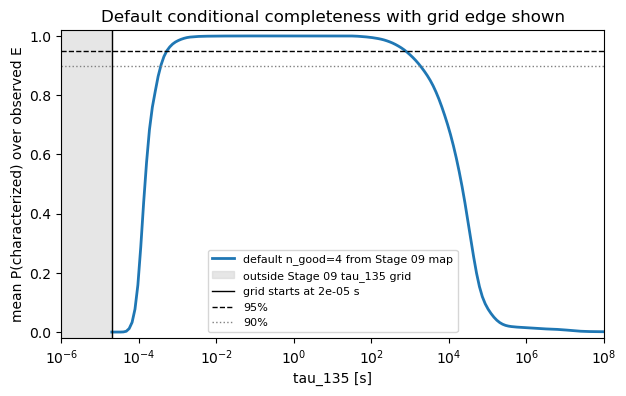

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau_grid, default_curve, label="default n_good=4 from Stage 09 map", linewidth=2)

# This shaded region is outside the cached Stage 09 tau_135 grid, not a computed zero-probability region.
left_display_limit = min(1e-6, tau_grid[0] / 20)
ax.axvspan(left_display_limit, tau_grid[0], color="lightgray", alpha=0.55, label="outside Stage 09 tau_135 grid")
ax.axvline(tau_grid[0], color="black", linestyle="-", linewidth=1, label=f"grid starts at {tau_grid[0]:.0e} s")

ax.axhline(0.95, color="black", linestyle="--", linewidth=1, label="95%")
ax.axhline(0.90, color="gray", linestyle=":", linewidth=1, label="90%")
ax.set_xscale("log")
ax.set_xlim(left_display_limit, tau_grid[-1])
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("tau_135 [s]")
ax.set_ylabel("mean P(characterized) over observed E")
ax.legend(fontsize=8)
ax.set_title("Default conditional completeness with grid edge shown")
plt.show()


## Sensitivity Variants

The fainter amplitude variants are the most important stress tests because the empirical amplitude prior is selected from detected high-confidence traps. Stage 10 recomputes these numerically from the Stage 08 `p_det` grid and the Stage 05 prior variants.

In [12]:
variant_names = [
    "default_n_good_4",
    "default_n_good_3",
    "faint_0p5_n_good_4",
    "faint_0p25_n_good_4",
    "default_n_good_4_excluding_160K_170K",
]

for name in variant_names:
    entry = summary["completeness_vs_tau_observed_E"][name]
    points = entry["representative_tau_seconds_to_mean_probability"]
    interval90 = entry["tau_intervals_mean_probability_ge_0p90"]
    interval95 = entry["tau_intervals_mean_probability_ge_0p95"]
    print("\n", name)
    print("  P4/P3 at 1e3 s:", points["1000"])
    print("  P4/P3 at 1e4 s:", points["10000"])
    print("  >=90% intervals:", interval90)
    print("  >=95% intervals:", interval95)



 default_n_good_4
  P4/P3 at 1e3 s: 0.9358390036582251
  P4/P3 at 1e4 s: 0.6855164861305783
  >=90% intervals: [{'tau_min_seconds': 0.00037232911332721395, 'tau_max_seconds': 1656.5757228879438, 'grid_count': 90}]
  >=95% intervals: [{'tau_min_seconds': 0.0006237728482718332, 'tau_max_seconds': 700.9905683929695, 'grid_count': 82}]

 default_n_good_3
  P4/P3 at 1e3 s: 0.9434670995013177
  P4/P3 at 1e4 s: 0.7216571070357453
  >=90% intervals: [{'tau_min_seconds': 0.00015755343578589248, 'tau_max_seconds': 1967.483577641052, 'grid_count': 96}]
  >=95% intervals: [{'tau_min_seconds': 0.00022224271065196535, 'tau_max_seconds': 832.5532074018749, 'grid_count': 89}]

 faint_0p5_n_good_4
  P4/P3 at 1e3 s: 0.8412745654453302
  P4/P3 at 1e4 s: 0.4639996884557104
  >=90% intervals: [{'tau_min_seconds': 0.15325717662511013, 'tau_max_seconds': 352.30019250590425, 'grid_count': 46}]
  >=95% intervals: [{'tau_min_seconds': 1.2073097368065744, 'tau_max_seconds': 37.65435166370771, 'grid_count': 21}]

## Method 2 Versus Method 3

Method 2 uses empirical bands from characterized traps. It is useful as a cross-check but it inherits data-starvation at warm temperatures and sharp band edges. Method 3 fills those regions with the analytic intensity model plus measured noise. A healthy comparison should show that Method 2 regions mostly lie inside high Method 3 probability, while Method 3 can extend beyond Method 2 where the empirical proxy is sparse.

In [13]:
m2 = summary["method2_empirical_band_comparison"]
keys = [
    "method2_recoverable_grid_fraction",
    "method3_p4_ge_0p8_grid_fraction",
    "fraction_method2_inside_method3_p4_ge_0p8",
    "fraction_method3_p4_ge_0p8_inside_method2",
    "grid_fraction_method3_high_not_method2",
    "grid_fraction_method2_not_method3_high",
]
for key in keys:
    print(f"{key}: {m2[key]}")

print("Temperatures with no empirical Method 2 band:", m2["temperatures_with_no_empirical_band"])


method2_recoverable_grid_fraction: 0.17775844570102944
method3_p4_ge_0p8_grid_fraction: 0.671451355661882
fraction_method2_inside_method3_p4_ge_0p8: 0.945078847199565
fraction_method3_p4_ge_0p8_inside_method2: 0.2501979414093428
grid_fraction_method3_high_not_method2: 0.5034556087187666
grid_fraction_method2_not_method3_high: 0.009762698757914069
Temperatures with no empirical Method 2 band: []


## Map View: Known Traps And The Unbounded Region

The unbounded region is not simply where `P4` is small. It is the subset where every measured temperature maps outside the Stage 08 `tau` grid, so the Stage 09 no-extrapolation policy assigns zero detection probability at all temperatures. Those populations require either different measurements or additional assumptions.

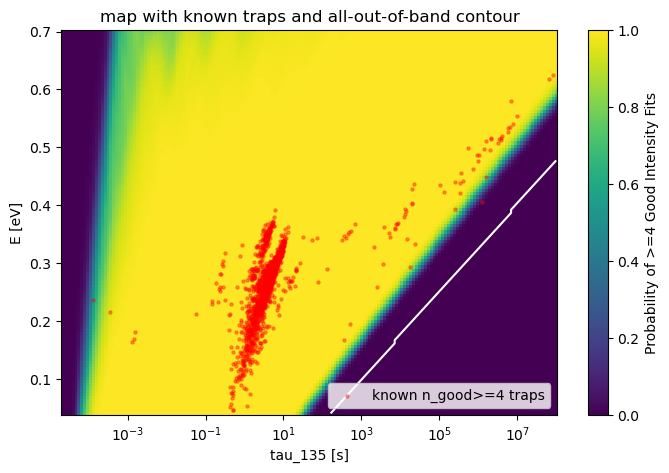

Unbounded grid fraction: 0.15238509496882702
E range: 0.04 to 0.4745 eV
tau_135 range: 177.0571976798964 to 100000000.0 s
max P4 in unbounded regime: 0.0


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
mesh = ax.pcolormesh(tau_grid, E_grid, p4_map.T, shading="auto", cmap="viridis", vmin=0, vmax=1)
ax.contour(tau_grid, E_grid, all_oob.T.astype(float), levels=[0.5], colors="white", linewidths=1.5)
ax.scatter(known_tau, known_E, s=5, c="red", alpha=0.35, label="known n_good>=4 traps")
ax.set_xscale("log")
ax.set_xlabel("tau_135 [s]")
ax.set_ylabel("E [eV]")
ax.set_title("map with known traps and all-out-of-band contour")
fig.colorbar(mesh, ax=ax, label="Probability of >=4 Good Intensity Fits")
ax.legend(loc="lower right")
plt.show()

unbounded = summary["unbounded_regime"]["all_temperatures_out_of_stage08_tau_band"]
print("Unbounded grid fraction:", unbounded["grid_fraction"])
print("E range:", unbounded["E_eV_min"], "to", unbounded["E_eV_max"], "eV")
print("tau_135 range:", unbounded["tau_135_seconds_min"], "to", unbounded["tau_135_seconds_max"], "s")
print("max P4 in unbounded regime:", unbounded["p4_max_in_regime"])


## Completeness Bounds In Energy Versus Cross-Section Space

The paper's characterized-trap figure uses `(sigma, E)` rather than `(tau_135, E)`. These are just different coordinates for the same thermal-emission model. For any point in this plot, Stage 10 computes

`tau_135 = exp(log_energy_cross_section(135 K, E, log(sigma)))`

and then looks up `P(n_good >= 4 | tau_135, E)` from the Stage 09 map. The contours below are therefore **completeness contours**, not exclusions of trap existence. They say where an observed-amplitude trap with that `(E, sigma)` would probably have been characterized by the pocket-pumping analysis.

Caveats:

- The probability is conditional on the Stage 05 observed/high-confidence amplitude prior.
- Regions outside the Stage 09 `tau_135` grid are left blank rather than extrapolated.
- The all-temperatures-out-of-band curve is a subset of the low-probability region. In the cleaned plot, low-probability space is left white so this boundary does not visually merge with a dark heatmap.
- Low-probability or all-out-of-band regions are weakly bounded by this measurement; they are not proven empty.

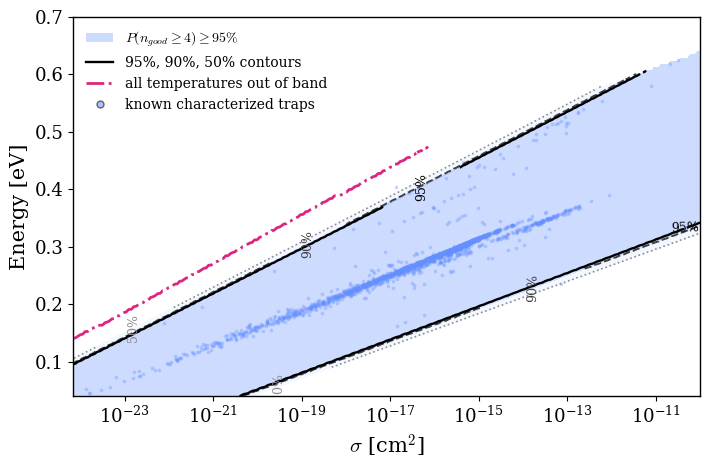

Observed sigma range: 1.3757011681195307e-24 to 3.232974905126293e-11 cm^2
Blank regions are outside the Stage 09 tau_135 grid and are not extrapolated.


In [98]:
import sys

if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from dipole import log_energy_cross_section


sigma_records = []
E_records_for_sigma = []
tau_records_for_sigma = []
with records4_path.open(newline="") as handle:
    for row in csv.DictReader(handle):
        sigma_records.append(np.exp(float(row["log_sigma"])))
        E_records_for_sigma.append(float(row["E_eV"]))
        tau_records_for_sigma.append(float(row["tau_135_seconds"]))

sigma_records = np.asarray(sigma_records, dtype=float)
E_records_for_sigma = np.asarray(E_records_for_sigma, dtype=float)
tau_records_for_sigma = np.asarray(tau_records_for_sigma, dtype=float)

# Use a paper-like sigma range, but include the observed range if it extends beyond this.
sigma_min = min(1e-23, np.nanmin(sigma_records) / 2)
sigma_max = max(1e-10, np.nanmax(sigma_records) * 2)
sigma_grid = np.geomspace(sigma_min, sigma_max, 260)
sigma_mesh, E_mesh = np.meshgrid(sigma_grid, E_grid)

tau_135_from_sigma_E = np.exp(log_energy_cross_section(135.0, E_mesh, np.log(sigma_mesh)))
log_tau_model = np.log(tau_135_from_sigma_E)
log_tau_grid = np.log(tau_grid)

# Interpolate the Stage 09 map along tau_135 at each energy. Leave out-of-grid regions blank.
p4_sigma_E = np.full_like(log_tau_model, np.nan, dtype=float)
all_oob_sigma_E = np.full_like(log_tau_model, np.nan, dtype=float)
for e_index in range(E_grid.size):
    in_tau_grid = (log_tau_model[e_index] >= log_tau_grid[0]) & (log_tau_model[e_index] <= log_tau_grid[-1])
    p4_sigma_E[e_index, in_tau_grid] = np.interp(
        log_tau_model[e_index, in_tau_grid],
        log_tau_grid,
        p4_map[:, e_index],
    )
    all_oob_sigma_E[e_index, in_tau_grid] = np.interp(
        log_tau_model[e_index, in_tau_grid],
        log_tau_grid,
        all_oob[:, e_index].astype(float),
    )

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Publication-style view: avoid coloring the low-probability region, because
# the all-out-of-band boundary is a subset of that region and otherwise sits
# on top of a dark purple heatmap.
paper_style = {
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
}

with plt.rc_context(paper_style):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # Filled bands show only the recoverable-completeness region. Areas below
    # P4=0.5 are intentionally left white rather than colored as a dark failure
    # region.
    ax.contourf(
        sigma_grid,
        E_grid,
        p4_sigma_E,
        levels=[0.5, 0.9, 0.95, 1.000001],
        colors=["#dbe7ff", "#98b8ff", "#648FFF"],
        alpha=0.32,
    )

    prob_levels = [0.5, 0.9, 0.95]
    contours = ax.contour(
        sigma_grid,
        E_grid,
        p4_sigma_E,
        levels=prob_levels,
        colors=["0.55", "0.25", "black"],
        linestyles=[":", "--", "-"],
        linewidths=[1.2, 1.4, 1.7],
    )
    ax.clabel(contours, inline=True, fmt={0.5: "50%", 0.9: "90%", 0.95: "95%"}, fontsize=9)

    blind_contour = ax.contour(
        sigma_grid,
        E_grid,
        all_oob_sigma_E,
        levels=[0.5],
        colors=["#DC267F"],
        linestyles=["-."],
        linewidths=[2.0],
    )

    ax.scatter(
        sigma_records,
        E_records_for_sigma,
        s=7,
        c="#648FFF",
        alpha=0.35,
        linewidths=0,
        label="known characterized traps",
    )

    ax.set_xscale("log")
    ax.set_xlim(sigma_grid[0], sigma_grid[-1])
    ax.set_ylim(E_grid[0], E_grid[-1])
    ax.set_xlabel(r"$\sigma$ [cm$^2$]")
    ax.set_ylabel("Energy [eV]")

    handles = [
        Patch(facecolor="#648FFF", alpha=0.32, edgecolor="none", label=r"$P(n_{good}\geq4) \geq 95\%$"),
        Line2D([0], [0], color="black", lw=1.7, label="95%, 90%, 50% contours"),
        Line2D([0], [0], color="#DC267F", lw=2.0, ls="-.", label="all temperatures out of band"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#648FFF", alpha=0.55, markersize=5, label="known characterized traps"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)

    fig.tight_layout()
    figure_path = cache / "figures" / "10_completeness_bounds_sigma_E_clean.png"
    figure_path.parent.mkdir(exist_ok=True)
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

print("Observed sigma range:", np.nanmin(sigma_records), "to", np.nanmax(sigma_records), "cm^2")
print("Blank regions are outside the Stage 09 tau_135 grid and are not extrapolated.")


## Required Checks

These are the Stage 10 stop-condition checks copied from the summary artifact. Any `FAIL` here means the final completeness statement should not be used without revisiting the model.

In [97]:
for key, value in summary["required_checks"].items():
    print(f"{key}: {value}")

print("\nStop conditions:")
for key, value in summary["stop_conditions"].items():
    print(f"{key}: {value}")


known_characterized_traps_mostly_high_probability: PASS
sensitivity_variants_are_numerical: PASS
final_claim_conditional_on_amplitude_prior_and_observed_E: PASS
recoverable_completeness_distinguished_from_unconditional_population_bound: PASS

Stop conditions:
known_traps_predominantly_low_probability: NOT_TRIGGERED
amplitude_sensitivity_dominates_unbounded: NOT_TRIGGERED_BUT_CONDITIONALITY_REQUIRED
claim_would_overstate_population_bound: NOT_TRIGGERED_AFTER_CONDITIONAL_WORDING


## How To Rerun Stage 10

From the repository root, rerun the numerical validation with:

```bash
wsl -e /home/ansh/miniforge3/envs/sensei_charge_traps/bin/python \
  /mnt/c/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/src/validation_sensitivity.py
```

Expected outputs are:

- `cache/10_validation_sensitivity_summary.json`
- `cache/10_completeness_statement.md`
- `cache/figures/10_known_trap_probability_hist.png`
- `cache/figures/10_completeness_vs_tau.png`
- `cache/figures/10_method2_vs_method3_hist.png`

The full rerun took about three minutes in the WSL conda environment because it recomputes the amplitude-prior sensitivity variants over the Stage 09 grid.